## **Time Series Analysis Task Notebook**

This notebook is designed to test you through various Time Series Analysis tasks using the Bike Sharing dataset. The tasks will help you develop essential skills in handling time-based data, including cleaning and preprocessing, feature engineering, and model building. You'll explore techniques such as creating lag and rolling window features, implementing linear regression for time series prediction, and applying XGBoost with hyperparameter tuning. Finally, you'll evaluate and compare the performance of the models, providing insights into their effectiveness. These tasks will enhance your understanding of time series analysis and prepare you for real-world forecasting challenges.

# **About the Dataset**
The Bike Sharing Dataset contains information about bike rental counts in the city of Washington, D.C., recorded at hourly intervals. The dataset provides data on various factors that influence bike rentals, including weather conditions, time of day, and seasonal factors. It includes several features such as temperature, humidity, wind speed, and day of the week, which can be used for building predictive models to forecast bike rental demand.

The dataset spans multiple years and captures the number of bikes rented at each hour of the day, making it ideal for time series analysis. By leveraging this data, you can explore patterns in bike rentals over time, uncover seasonality, and implement models for predicting future rental demand.





## **Key Attributes in the Dataset:**

**instant:** Record index.

**dteday:** Date of the observation.

**season:** The season (1: Spring, 2: Summer, 3: Fall, 4: Winter).

**yr:** Year (0: 2011, 1: 2012).

**mnth:** Month of the year (1 to 12).

**hour:** Hour of the day (0 to 23).

**holiday:** Whether the day is a holiday (1: Yes, 0: No).

**weekday:** Day of the week (0 to 6).

**workingday:** Whether it's a working day (1: Yes, 0: No).

**weathersit:** Weather condition (1: Clear, 2: Mist, 3: Light Rain, 4: Heavy Rain).

**temp:** Temperature (normalized).

**hum:** Humidity (normalized).

**windspeed:** Wind speed (normalized).

**cnt:** The total number of bike rentals at that hour.

This dataset offers a comprehensive set of features to explore and analyze bike-sharing patterns, making it an excellent resource for time series forecasting tasks.

## **Exercise**

1. Load the [dataset](https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset) from Kaggle. Use the "hour.csv" file.

In [1]:
import os
import kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

c:\Users\nikol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\nikol\.cache\kagglehub\datasets\lakshmi25npathi\bike-sharing-dataset\versions\1


1. Load the [dataset](https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset) from Kaggle. Use the "hour.csv" file.

In [3]:
dataset_path = "C:/Users/nikol/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1"

files = os.listdir(dataset_path)
files


['day.csv', 'hour.csv', 'Readme.txt']

In [4]:
days_path = "C:/Users/nikol/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1/day.csv"
hours_path = "C:/Users/nikol/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1/hour.csv"

days_data = pd.read_csv(days_path)
hours_data = pd.read_csv(hours_path)

In [5]:
print('Days dataset:' + '\n' + str(days_data.head()))
print("--------------------------------------------------------------------------------------")
print('Hours dataset:' + '\n' + str(hours_data.head()))

Days dataset:
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
------------

2. Visualize the structure of the dataset using appropriate libraries and plots.

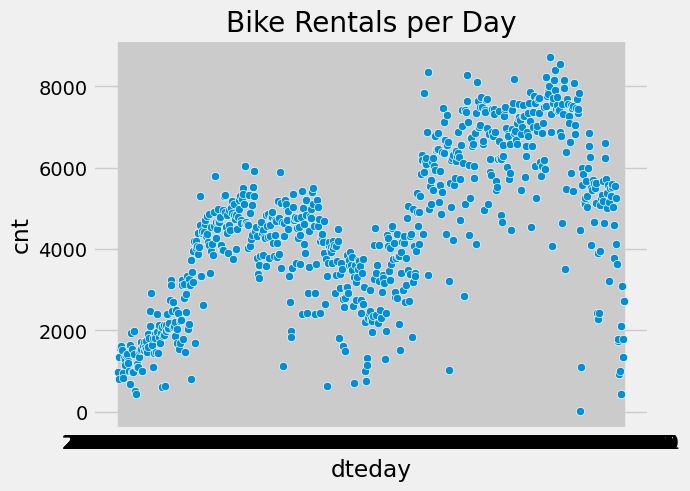

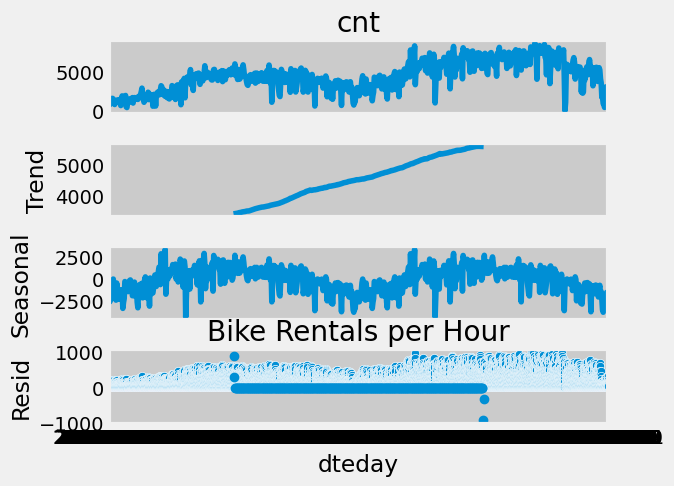

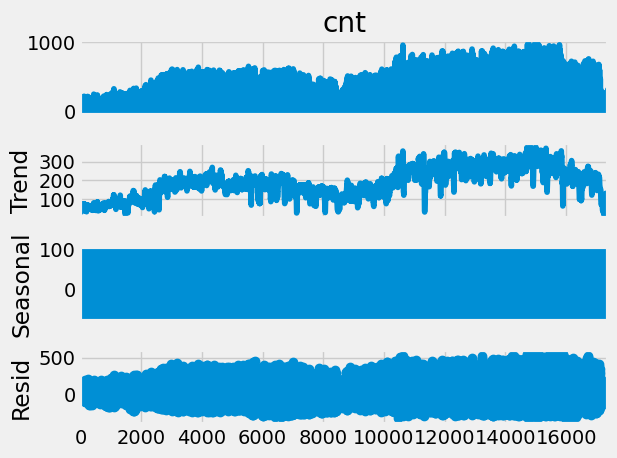

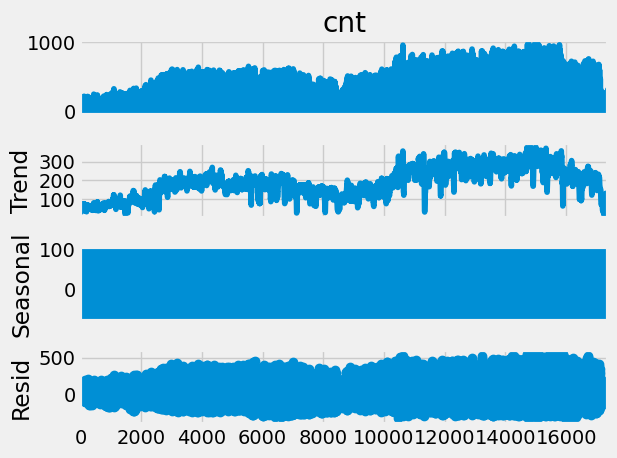

In [6]:
# Days dataset
sns.scatterplot(x='dteday', y='cnt', data=days_data)
plt.title('Bike Rentals per Day')
plt.show()

# Perform seasonal decomposition
result_days = seasonal_decompose(days_data['cnt'], model='additive', period=365)
result_days.plot()

# Hours dataset
sns.scatterplot(x='dteday', y='cnt', data=hours_data)
plt.title('Bike Rentals per Hour')
plt.show()

# Perform seasonal decomposition
result_hours = seasonal_decompose(hours_data['cnt'], model='additive', period=24)
result_hours.plot()

3. Clean and pre-process the dataset as required and prepare the data for modelling.


In [7]:
# 3. Clean and pre-process the dataset as required and prepare the data for modelling.
hours_data['dteday'] = pd.to_datetime(hours_data['dteday'])
hours_data['hour'] = hours_data['hr']
hours_data['day_of_week'] = hours_data['dteday'].dt.dayofweek
hours_data['month'] = hours_data['dteday'].dt.month
hours_data['year'] = hours_data['dteday'].dt.year
hours_data.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,atemp,hum,windspeed,casual,registered,cnt,hour,day_of_week,month,year
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.2879,0.81,0.0,3,13,16,0,5,1,2011
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0.2727,0.80,0.0,8,32,40,1,5,1,2011
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0.2727,0.80,0.0,5,27,32,2,5,1,2011
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0.2879,0.75,0.0,3,10,13,3,5,1,2011
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.2879,0.75,0.0,0,1,1,4,5,1,2011


4. Create the lag and rolling windows features for the "cnt" column such as: 1 day lag, 1 week lag, 1 month, etc. and last 3 day rolling mean, last 3 hours rolling mean, etc. But it should be based on your dataset and what makes sense for this dataset.


In [8]:
#use shift(1), (7) (30), (365) to create lag features for the target variable 'cnt'
hours_data['cnt_lag_1'] = hours_data['cnt'].shift(1)
hours_data['cnt_lag_7'] = hours_data['cnt'].shift(7)
hours_data['cnt_lag_30'] = hours_data['cnt'].shift(30)
hours_data['cnt_lag_365'] = hours_data['cnt'].shift(365)

# rolling
hours_data['cnt_rolling_3'] = hours_data['cnt'].rolling(window=3).mean()
hours_data['cnt_rolling_7'] = hours_data['cnt'].rolling(window=7).mean()
hours_data['cnt_rolling_30'] = hours_data['cnt'].rolling(window=30).mean()
hours_data['cnt_rolling_365'] = hours_data['cnt'].rolling(window=365).mean()

hours_data

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,month,year,cnt_lag_1,cnt_lag_7,cnt_lag_30,cnt_lag_365,cnt_rolling_3,cnt_rolling_7,cnt_rolling_30,cnt_rolling_365
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,1,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,1,2011,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,1,2011,40.0,NaN,NaN,NaN,29.333333,NaN,NaN,NaN
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,1,2011,32.0,NaN,NaN,NaN,28.333333,NaN,NaN,NaN
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,1,2011,13.0,NaN,NaN,NaN,15.333333,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,...,12,2012,122.0,224.0,169.0,417.0,135.000000,197.714286,114.166667,115.257534
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,...,12,2012,119.0,203.0,160.0,356.0,110.000000,181.428571,111.800000,114.526027
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,...,12,2012,89.0,247.0,138.0,310.0,99.333333,159.000000,110.200000,113.923288
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,...,12,2012,90.0,315.0,133.0,338.0,80.000000,122.714286,107.800000,113.164384


5. Implement linear regression to predict how many bikes will be rented each hour of the last week and evaluate using appropriate metrics.

In [14]:
features = ['hour', 'day_of_week', 'month', 'year', 'cnt_lag_1', 'cnt_lag_7', 'cnt_lag_30', 'cnt_lag_365',
            'cnt_rolling_3', 'cnt_rolling_7', 'cnt_rolling_30', 'cnt_rolling_365']
target = 'cnt'
train_data = hours_data.dropna()
X_train = train_data[features]
y_train = train_data[target]
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
# Predict bikes will be rented each hour of the last week
X_test = hours_data[features].tail(168)
y_test = hours_data[target].tail(168)
y_pred_lr = model_lr.predict(X_test)
# show
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lr})
print(results)
# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f"Linear Regression - MSE: {mse_lr}, MAE: {mae_lr}")

       Actual   Predicted
17211      11   48.970046
17212      13   23.037201
17213      13   19.092725
17214       7   16.085306
17215       1   14.454764
...       ...         ...
17374     119  115.314069
17375      89   73.325748
17376      90   85.184058
17377      61   71.248972
17378      49   83.781426

[168 rows x 2 columns]
Linear Regression - MSE: 640.9672149488459, MAE: 19.48648686507245


The linear regression model gives a baseline prediction. The RMSE tells us on average how many bikes off our predictions are. The MAE gives a similar measure but is less sensitive to large errors.

6. Implement XGBoost to predict how many bikes will be rented each hour of the last week and evaluate using appropriate metrics.

In [12]:
# 6. Implement XGBoost to predict how many bikes will be rented each hour of the last week and evaluate using appropriate metrics.
model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test) 
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
# show
results_xgb = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_xgb})
print(results_xgb)
print(f"XGBoost - MSE: {mse_xgb}, MAE: {mae_xgb}")

       Actual  Predicted
17211      11  13.547039
17212      13   6.321427
17213      13   7.559597
17214       7   6.029000
17215       1   4.762809
...       ...        ...
17374     119  98.771637
17375      89  76.122269
17376      90  72.917290
17377      61  58.827793
17378      49  49.325214

[168 rows x 2 columns]
XGBoost - MSE: 256.42449951171875, MAE: 9.766749382019043


7. Experiment with predicting different time periods, such as use all data to predict bike rentals for just the next day (24 hours) or the next entire month and then see how much better or worse the model gets

In [16]:
# Next day (24 hours)
test_day = hours_data[hours_data['dteday'] == '2012-12-31'].dropna()
X_test_day = test_day[features]
y_test_day = test_day[target]
y_pred_day = model_xgb.predict(X_test_day)

rmse_day = np.sqrt(mean_squared_error(y_test_day, y_pred_day))
mae_day = mean_absolute_error(y_test_day, y_pred_day)
print(f"Next Day (24h) - RMSE: {rmse_day}, MAE: {mae_day}")

# Next month (last 30 days)
test_month = hours_data[hours_data['dteday'] >= '2012-12-01'].dropna()
X_test_month = test_month[features]
y_test_month = test_month[target]
y_pred_month = model_xgb.predict(X_test_month)

rmse_month = np.sqrt(mean_squared_error(y_test_month, y_pred_month))
mae_month = mean_absolute_error(y_test_month, y_pred_month)
print(f"Next Month (30 days) - RMSE: {rmse_month}, MAE: {mae_month}")

Next Day (24h) - RMSE: 30.840493630343875, MAE: 19.253149032592773
Next Month (30 days) - RMSE: 16.66613819556035, MAE: 10.894144058227539
